In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os.path as osp
import os

---

In [3]:
# folder = 'results/ions_dipole_test_1M_steps_20250918_155438'
folder = 'results_prod/fig5/ions_dipole_sigma_-0.16_20251025_225033'
df = pd.read_csv(osp.join(folder, 'simulation_data.csv'))
df.head()

,step,time_s,n_atoms,energy_pot,energy_tail,energy_total,temperature,volume,density,pressure_ideal,pressure_virial,pressure_tail,pressure_total,mu_id,acceptance_total
0,100,1.150240,886,684.7867,0.0,684.7867,298,1200.0,0.498333,1.234725,0.705967,0.0,1.940692,1.676365,0.620
1,200,1.805007,886,649.7434,0.0,649.7434,298,1200.0,0.498333,1.234725,0.703945,0.0,1.938670,1.676365,0.615
2,300,2.436995,886,614.5200,0.0,614.5200,298,1200.0,0.498333,1.234725,0.706042,0.0,1.940767,1.676365,0.590
3,400,3.087929,886,587.0892,0.0,587.0892,298,1200.0,0.498333,1.234725,0.700768,0.0,1.935493,1.676365,0.570
4,500,3.724268,886,596.1991,0.0,596.1991,298,1200.0,0.498333,1.234725,0.701378,0.0,1.936103,1.676365,0.560


In [4]:
begin = 0

In [5]:
len(df["energy_total"])

8460

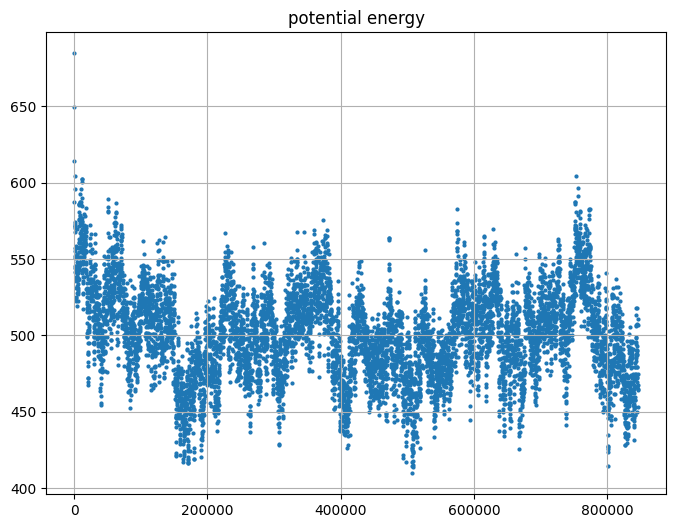

In [6]:
plt.figure(figsize=(8, 6))
plt.grid(True)
plt.scatter(df["step"][begin:], df["energy_total"][begin:], s=4)
# plt.ylim(bottom=-1000, top=100000)
plt.title('potential energy')
plt.show()

In [21]:
np.mean(df["pressure_virial"][1000:]) * 16.6054e-3

np.float64(-0.00734985709377248)

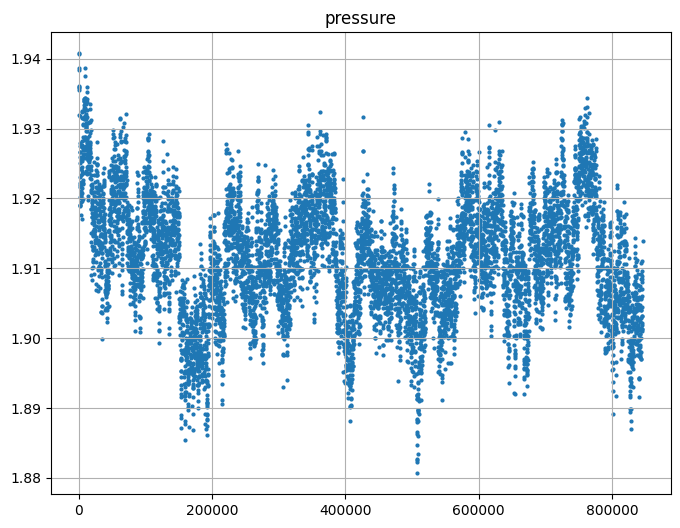

In [7]:
plt.figure(figsize=(8, 6))
plt.grid(True)
plt.scatter(df["step"][begin:], df["pressure_total"][begin:], s=4)
# plt.ylim(bottom=-10, top=10)
plt.title('pressure')
plt.show()

In [8]:
np.mean(df["density"][begin:])

np.float64(0.662)

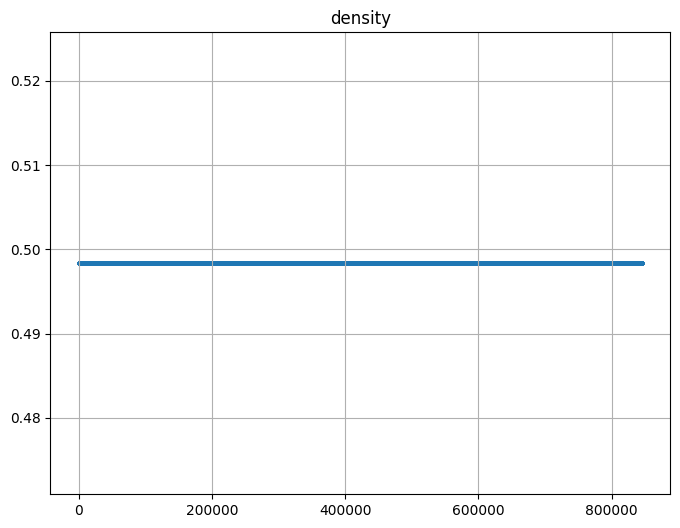

In [8]:
plt.figure(figsize=(8, 6))
plt.grid(True)
plt.scatter(df["step"][begin:], df["density"][begin:], s=4)
# plt.ylim(bottom=-10, top=10)
plt.title('density')
plt.show()

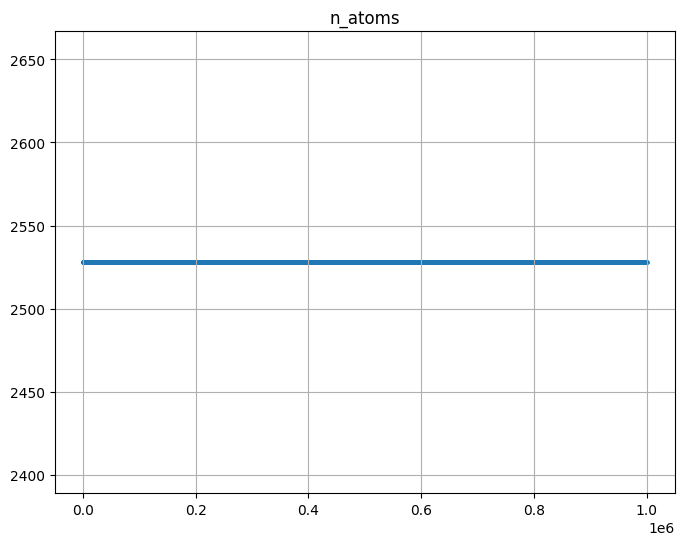

In [9]:
plt.figure(figsize=(8, 6))
plt.grid(True)
plt.scatter(df["step"][begin:], df["n_atoms"][begin:], s=4)
# plt.ylim(bottom=-10, top=10)
plt.title('n_atoms')
plt.show()

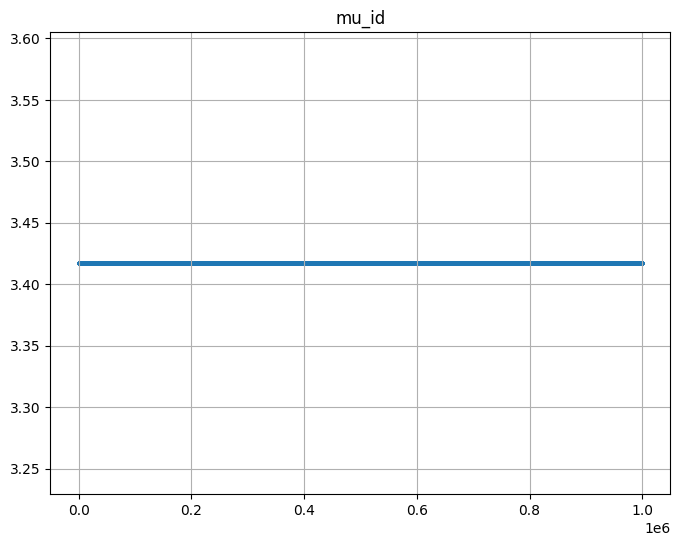

In [23]:
plt.figure(figsize=(8, 6))
plt.grid(True)
plt.scatter(df["step"][begin:], df["mu_id"][begin:], s=4)
# plt.ylim(bottom=-10, top=10)
plt.title('mu_id')
plt.show()

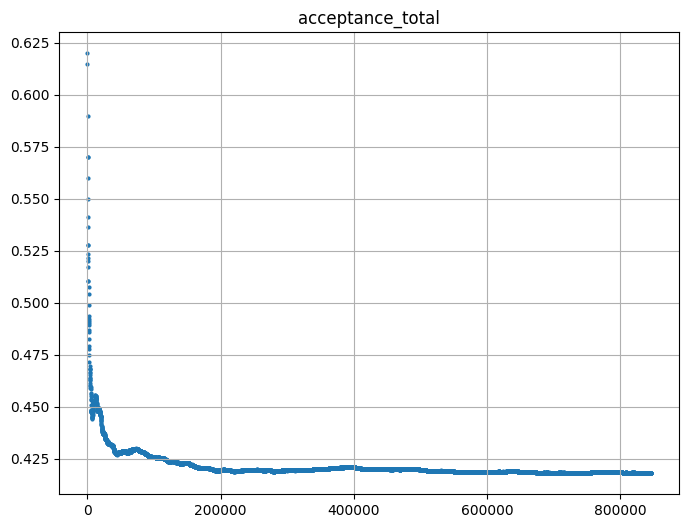

In [9]:
plt.figure(figsize=(8, 6))
plt.grid(True)
plt.scatter(df["step"][begin:], df["acceptance_total"][begin:], s=4)
# plt.ylim(bottom=-10, top=10)
plt.title('acceptance_total')
plt.show()

In [ ]:
plt.figure(figsize=(8, 6))
plt.grid(True)
plt.scatter(df["step"][begin:], df["mu"][begin:], s=4)
# plt.ylim(bottom=-10, top=10)
plt.title('n_atoms')
plt.show()

## Visualization of the phase diagram in the NVT ensemble

0.19999999999999998 -0.021406852278078 -0.010694019999999999
0.39999999999999997 -0.051820038253154 -0.042776079999999994
0.6 -0.037944072556132004 -0.09624619
0.7999999999999999 0.018307410571154 -0.17110430000000001
1.0 0.26978004907742 -0.2673505
1.2 0.9901847849400001 -0.3849848
1.4000000000000001 2.1034900114 -0.524007
1.5999999999999999 4.6383037312 -0.6844174000000001
[np.float64(0.16789912772192198), np.float64(0.30540388174684596), np.float64(0.465809737443868), np.float64(0.647203110571154), np.float64(1.00242954907742), np.float64(1.80519998494), np.float64(2.9794830114), np.float64(5.553886331199999)]
[np.float64(0.009256832744956821), np.float64(0.03284296439639087), np.float64(0.05694044587874775), np.float64(0.07885485721932894), np.float64(0.12448072110433034), np.float64(0.21989782641541683), np.float64(0.28387560943145457), np.float64(0.2679606265198969)]


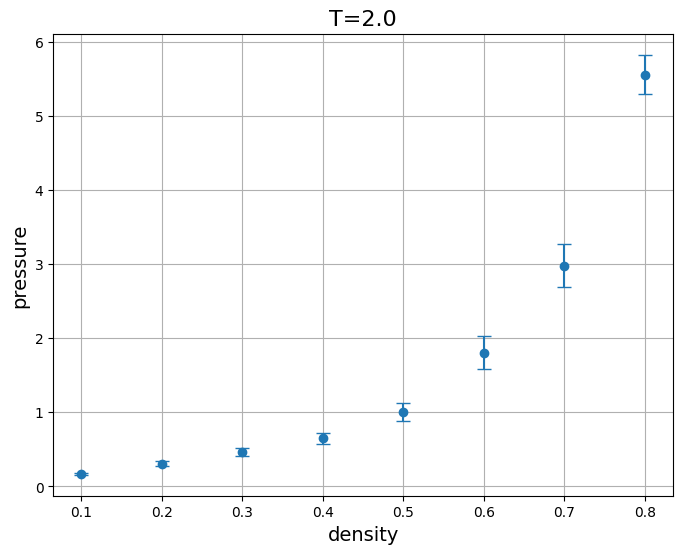

In [59]:
T = "2.0"
rhos = ['0.'+str(i) for i in range(1, 9)]
# rhos = ['0.'+str(i) for i in range(1, 9)] + ['0.75']

mean_pressure_list = []
std_pressure_list = []

begin = 5000
order = -1

for rho in rhos:
    candidates = []
    for folder in os.listdir('results'):
        if folder.startswith('lj_nvt_rho_'+rho+'_T_'+T):
            candidates.append(folder)

    candidates.sort(key=lambda x: int(x.split('_')[-1]))
    assert len(candidates) > 0, f"No results found for rho={rho}, T={T}"

    df = pd.read_csv(osp.join('results',candidates[order], 'simulation_data.csv'))
    mean_pressure_ideal = np.mean(df["pressure_ideal"][begin:])
    mean_pressure_virial = np.mean(df["pressure_virial"][begin:])
    mean_pressure_tail = np.mean(df["pressure_tail"][begin:])
    print(mean_pressure_ideal, mean_pressure_virial, mean_pressure_tail)
    mean_pressure_list.append(mean_pressure_ideal + mean_pressure_virial + mean_pressure_tail)
    std_pressure_list.append(np.std(df["pressure_total"][begin:]))
    # mean_pressure_list.append(np.mean(df["pressure_conf"][begin:]))
    # std_pressure_list.append(np.std(df["pressure_conf"][begin:]))

print(mean_pressure_list)
print(std_pressure_list)

plt.figure(figsize=(8, 6))
plt.grid(True)

plt.errorbar(list(map(float, rhos)), mean_pressure_list, yerr=std_pressure_list, fmt='o', capsize=5)
# plt.scatter(df["step"][begin:], df["pressure_total"][begin:], s=4)
plt.xlabel('density', fontsize=14)
plt.ylabel('pressure', fontsize=14)
plt.title(f'T={T}', fontsize=16)
plt.show()


/tmp/ipykernel_99430/1991302500.py:44: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


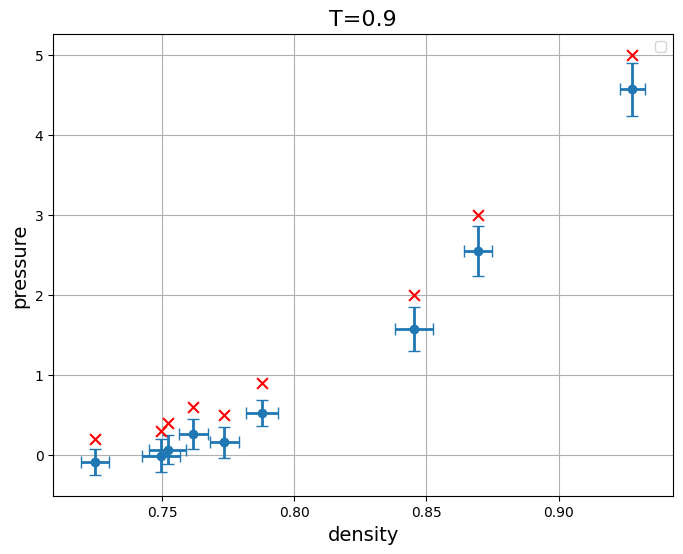

In [52]:
T = "0.9"
presses = ['0.2', '0.3', '0.4', '0.5', '0.6', '0.9', '2.0', '3.0', '5.0']

mean_pressure_list = []
std_pressure_list = []

mean_rho_list = []
std_rho_list = []

# For plotting target pressure points
target_pressures = []

for press in presses:
    for folder in os.listdir('results'):
        if folder.startswith('lj_npt_press_'+press+'_T_'+T):
            df = pd.read_csv(osp.join('results',folder, 'simulation_data.csv'))
            begin = 8000
            mean_p = np.mean(df["pressure_total"][begin:])
            std_p = np.std(df["pressure_total"][begin:])
            mean_rho = np.mean(df["density"][begin:])
            std_rho = np.std(df["density"][begin:])
            mean_pressure_list.append(mean_p)
            std_pressure_list.append(std_p)
            mean_rho_list.append(mean_rho)
            std_rho_list.append(std_rho)
            # For target pressure scatter
            target_pressures.append(float(press))

plt.figure(figsize=(8, 6))
plt.grid(True, zorder=1)

# Error bars in both x (density) and y (pressure)
plt.errorbar(mean_rho_list, mean_pressure_list,
             xerr=std_rho_list, yerr=std_pressure_list,
             fmt='o', capsize=4, linewidth=2, zorder=2)

# Scatter target pressure points (as horizontal lines at target pressure)
plt.scatter(mean_rho_list, target_pressures,
            color='red', marker='x', s=60, zorder=3)

plt.xlabel('density', fontsize=14)
plt.ylabel('pressure', fontsize=14)
plt.title(f'T={T}', fontsize=16)
plt.legend()
plt.show()


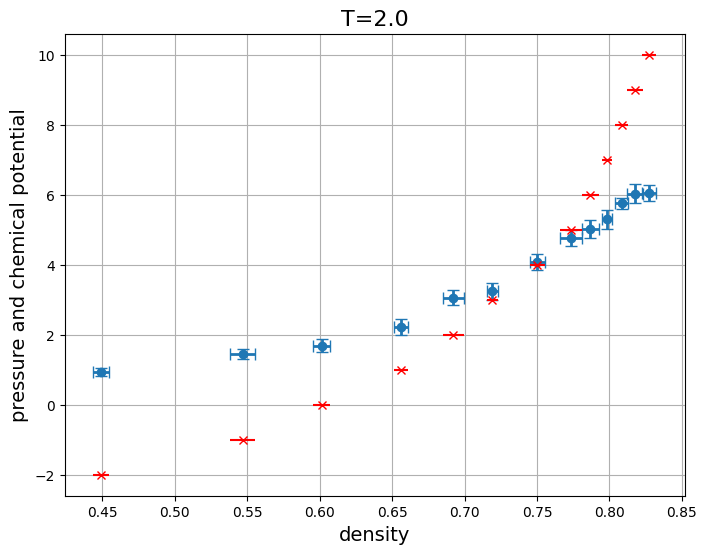

In [131]:
T = "2.0"
# presses = ['0.2', '0.3', '0.4', '0.5', '0.6', '0.9', '2.0', '3.0', '5.0']
mus = ['-2.0', '-1.0', '0.0', '1.0', '2.0', '3.0', '4.0', '5.0', '6.0', '7.0', '8.0', '9.0', '10.0']

mean_pressure_list = []
std_pressure_list = []

mean_rho_list = []
std_rho_list = []

# For plotting target pressure points
target_pressures = []

for mu in mus:
    for folder in os.listdir('results'):
        if folder.startswith('lj_muVT_mu_'+mu+'_T_'+T):
            df = pd.read_csv(osp.join('results',folder, 'simulation_data.csv'))
            begin = 15000
            mean_p = np.mean(df["pressure_total"][begin:])
            std_p = np.std(df["pressure_total"][begin:])
            mean_rho = np.mean(df["density"][begin:])
            std_rho = np.std(df["density"][begin:])
            mean_pressure_list.append(mean_p)
            std_pressure_list.append(std_p)
            mean_rho_list.append(mean_rho)
            std_rho_list.append(std_rho)

plt.figure(figsize=(8, 6))
plt.grid(True, zorder=1)

# Error bars in both x (density) and y (pressure)
plt.errorbar(mean_rho_list, mean_pressure_list,
             xerr=std_rho_list, yerr=std_pressure_list,
             fmt='o', capsize=4, linewidth=2, zorder=2)

# Scatter target pressure points (as horizontal lines at target pressure)
plt.errorbar(mean_rho_list, list(map(float, mus)),
            xerr=std_rho_list, yerr=None,
            color='red', fmt='x', zorder=3)

plt.xlabel('density', fontsize=14)
plt.ylabel('pressure and chemical potential', fontsize=14)
plt.title(f'T={T}', fontsize=16)
plt.show()


In [20]:
len(df["pressure_total"])

1000

---

Reading trajectory from results/lj_muVT_wall_h_4.0_20250817_185259/trajectory.xyz...
Loaded 50000 frames with 64 particles in the first frame


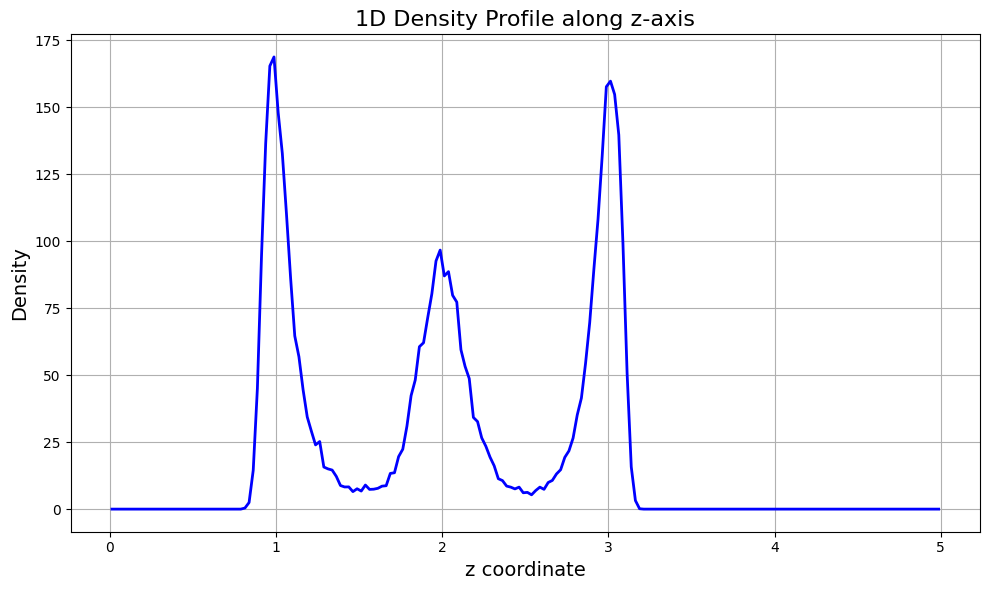

In [21]:
import numpy as np
import matplotlib.pyplot as plt
import os.path as osp
from collections import defaultdict

def read_xyz_trajectory(filename):
    """Read an extended XYZ trajectory file and return coordinates for each frame."""
    frames = []
    current_frame = []

    with open(filename, 'r') as f:
        lines = f.readlines()

    i = 0
    while i < len(lines):
        try:
            n_atoms = int(lines[i].strip())
            # Skip the comment line
            i += 2

            frame_coords = []
            for j in range(n_atoms):
                if i + j >= len(lines):
                    break

                parts = lines[i + j].strip().split()
                if len(parts) >= 4:  # At least x, y, z coordinates after atom type
                    x, y, z = float(parts[1]), float(parts[2]), float(parts[3])
                    frame_coords.append([x, y, z])

            if frame_coords:
                frames.append(np.array(frame_coords))

            i += n_atoms
        except (ValueError, IndexError):
            i += 1

    return frames

def calculate_density_profile(frames, axis=2, n_bins=100, box_size=[7.0, 7.0, 5.0]):
    """Calculate 1D density profile along specified axis."""
    # Initialize histogram bins
    bins = np.linspace(0, box_size[axis], n_bins + 1)
    bin_width = box_size[axis] / n_bins
    bin_centers = bins[:-1] + bin_width / 2

    # Accumulate density across all frames
    density_profile = np.zeros(n_bins)

    for frame in frames:
        # Extract coordinates along the specified axis (0=x, 1=y, 2=z)
        coords_along_axis = frame[:, axis]

        # Calculate histogram for this frame
        hist, _ = np.histogram(coords_along_axis, bins=bins)
        density_profile += hist

    # Normalize by number of frames and bin volume
    density_profile = density_profile / len(frames) / bin_width

    return bin_centers, density_profile

# Example usage
# trajectory_file = "results/lj_muVT_wall_20250815_233829/trajectory.xyz"
# trajectory_file = "results/lj_muVT_wall_20250816_002153/trajectory.xyz"
trajectory_file = "results/lj_muVT_wall_h_4.0_20250817_185259/trajectory.xyz"


# Read trajectory
print(f"Reading trajectory from {trajectory_file}...")
frames = read_xyz_trajectory(trajectory_file)
print(f"Loaded {len(frames)} frames with {len(frames[0])} particles in the first frame")

begin = 30000
# Calculate density profile along z-axis
bin_centers, density_profile = calculate_density_profile(frames[begin:], axis=2, n_bins=200)

# Plot density profile
plt.figure(figsize=(10, 6))
plt.plot(bin_centers, density_profile, 'b-', linewidth=2)
plt.grid(True)
plt.xlabel('z coordinate', fontsize=14)
plt.ylabel('Density', fontsize=14)
plt.title('1D Density Profile along z-axis', fontsize=16)
plt.tight_layout()
plt.show()


---

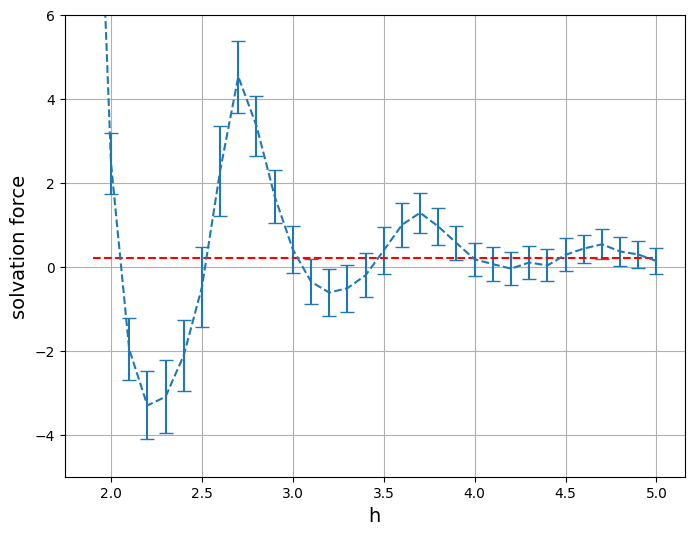

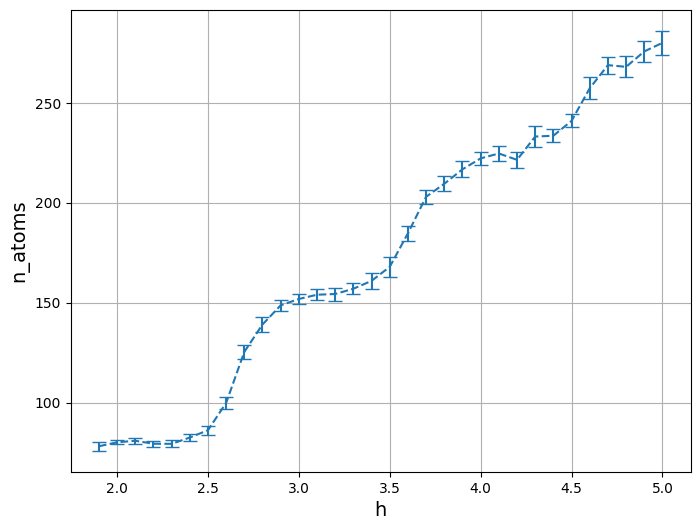

In [49]:
# H = [str(i.round(1)) for i in np.arange(1.8, 4.1, 0.2)]
H = [str(i.round(1)) for i in np.arange(1.9, 5.1, 0.1)]

mean_solvation_force_list = []
std_solvation_force_list = []

mean_n_atoms_list = []
std_n_atoms_list = []

begin = 50000
order = -1

for h in H:
    candidates = []
    for folder in os.listdir('results'):
        if folder.startswith('lj_muVT_wall_h_'+h):
            candidates.append(folder)

    candidates.sort(key=lambda x: int(x.split('_')[-1]))
    assert len(candidates) > 0, f"No results found for h={h}"

    df = pd.read_csv(osp.join('results',candidates[order], 'simulation_data.csv'))
    mean_solvation_force_list.append(np.mean(df["solvation_force"][begin:]))
    std_solvation_force_list.append(np.std(df["solvation_force"][begin:]))
    mean_n_atoms_list.append(np.mean(df["n_atoms"][begin:]))
    std_n_atoms_list.append(np.std(df["n_atoms"][begin:]))

plt.figure(figsize=(8, 6))
plt.grid(True)

start_point = 0
plt.errorbar(np.array(list(map(float, H)))[start_point:], mean_solvation_force_list[start_point:], yerr=std_solvation_force_list[start_point:], fmt='--', capsize=5)
plt.hlines(0.2, float(H[0]), float(H[-1]), colors='red', linestyles='--')
# plt.errorbar(list(map(float, H)), mean_n_atoms_list, yerr=std_n_atoms_list, fmt='o', capsize=5)
# plt.scatter(df["step"][begin:], df["pressure_total"][begin:], s=4)
plt.xlabel('h', fontsize=14)
plt.ylabel('solvation force', fontsize=14)
plt.ylim(-5, 6)
# plt.title(f'T={T}', fontsize=16)
plt.show()


plt.figure(figsize=(8, 6))
plt.grid(True)

plt.errorbar(np.array(list(map(float, H))), mean_n_atoms_list, yerr=std_n_atoms_list, fmt='--', capsize=5)
plt.xlabel('h', fontsize=14)
plt.ylabel('n_atoms', fontsize=14)
# plt.title(f'T={T}', fontsize=16)
plt.show()

---

112.8646 -221.06308567999997 0.0
107.2214 -230.43177498 0.0
102.11559999999999 -220.70418504 0.0
97.47396000000003 -188.81433868 0.0
89.35113 -168.17465667 0.0
82.47797000000001 -163.71217073 0.0
[np.float64(-1.7966793179988716), np.float64(-2.0459582272502534), np.float64(-1.9692112048283887), np.float64(-1.5167434700989004), np.float64(-1.3088961261839414), np.float64(-1.348926410551213)]
[np.float64(0.22903517722442263), np.float64(0.18788036353834536), np.float64(0.2065139425592515), np.float64(0.16972419271756883), np.float64(0.25632882073775876), np.float64(0.1920408833622198)]


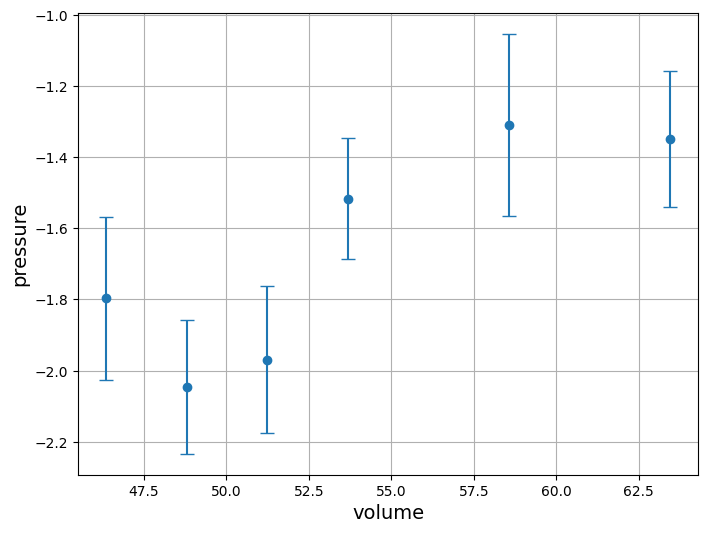

In [25]:
# vs = [48.80, 51.24, 53.68, 54.66, 63.44]
vs = [46.36, 48.80, 51.24, 53.68, 58.56, 63.44]

mean_pressure_list = []
std_pressure_list = []

begin = 40000
order = -1

for v in vs:
    candidates = []
    for folder in os.listdir('results'):
        if folder.startswith('KCl_nvt_v_'+str(v)):
            candidates.append(folder)

    candidates.sort(key=lambda x: int(x.split('_')[-1]))
    assert len(candidates) > 0, f"No results found for rho={rho}, T={T}"

    df = pd.read_csv(osp.join('results',candidates[order], 'simulation_data.csv'))
    mean_pressure_ideal = np.mean(df["pressure_ideal"][begin:])
    mean_pressure_virial = np.mean(df["pressure_virial"][begin:])
    mean_pressure_tail = np.mean(df["pressure_tail"][begin:])
    print(mean_pressure_ideal, mean_pressure_virial, mean_pressure_tail)
    # mean_pressure_list.append(np.mean(df["pressure_ideal"][begin:]))
    mean_pressure_list.append(np.mean(df["pressure_total"][begin:]) * 16.6054e-3)
    std_pressure_list.append(np.std(df["pressure_total"][begin:]) * 16.6054e-3)
    # mean_pressure_list.append(np.mean(df["pressure_conf"][begin:]))
    # std_pressure_list.append(np.std(df["pressure_conf"][begin:]))

print(mean_pressure_list)
print(std_pressure_list)

plt.figure(figsize=(8, 6))
plt.grid(True)

plt.errorbar(list(map(float, vs)), mean_pressure_list, yerr=std_pressure_list, fmt='o', capsize=5)
# plt.scatter(df["step"][begin:], df["pressure_total"][begin:], s=4)
plt.xlabel('volume', fontsize=14)
plt.ylabel('pressure', fontsize=14)
plt.show()


---

### Visualise $C_+$ from $C_z$

In [47]:
import numpy as np
import matplotlib.pyplot as plt
import os
import os.path as osp
import yaml
from scipy.optimize import curve_fit

In [68]:
path = 'results_prod/fig_6'

C_z_list = []
C_Na_list = []
C_Cl_list = []
# Define the exponential fitting function
def exp_func(x, a, b, c, d):
    return a * np.exp(b * x - c) + d

for folder in os.listdir(path):
    data_file = osp.join(path, folder, "density_profile_Na_Cl.npz")
    data = np.load(data_file)

    config_file = osp.join(path, folder, "config_backup.yaml")
    with open(config_file, "r") as f:
        config = yaml.safe_load(f)

    C_z_list.append(config['Cz'])

    # Fit the number density for Na
    z = data['z_centers']
    nd = data['Na_number_density']
    mask = z >= config['r_Na']
    z_fit = z[mask]
    nd_fit = nd[mask]

    # Initial guess for curve_fit
    p0 = [nd_fit.max(), -1.0, 0, nd_fit.min()]
    popt, pcov = curve_fit(exp_func, z_fit, nd_fit, p0=p0)

    C_Na_list.append(exp_func(config['r_Na'], *popt) * 1.66053907)

    # Fit the number density for Cl
    z = data['z_centers']
    nd = data['Cl_number_density']
    mask = z <= config['H'] - config['r_Cl']
    z_fit = z[mask]
    nd_fit = nd[mask]

    # Initial guess for curve_fit
    p0 = [nd_fit.max(), 1.0, config['H'] - config['r_Cl'], nd_fit.min()]
    popt, pcov = curve_fit(exp_func, z_fit, nd_fit, p0=p0)

    C_Cl_list.append(exp_func(config['H'] - config['r_Cl'], *popt) * 1.66053907)


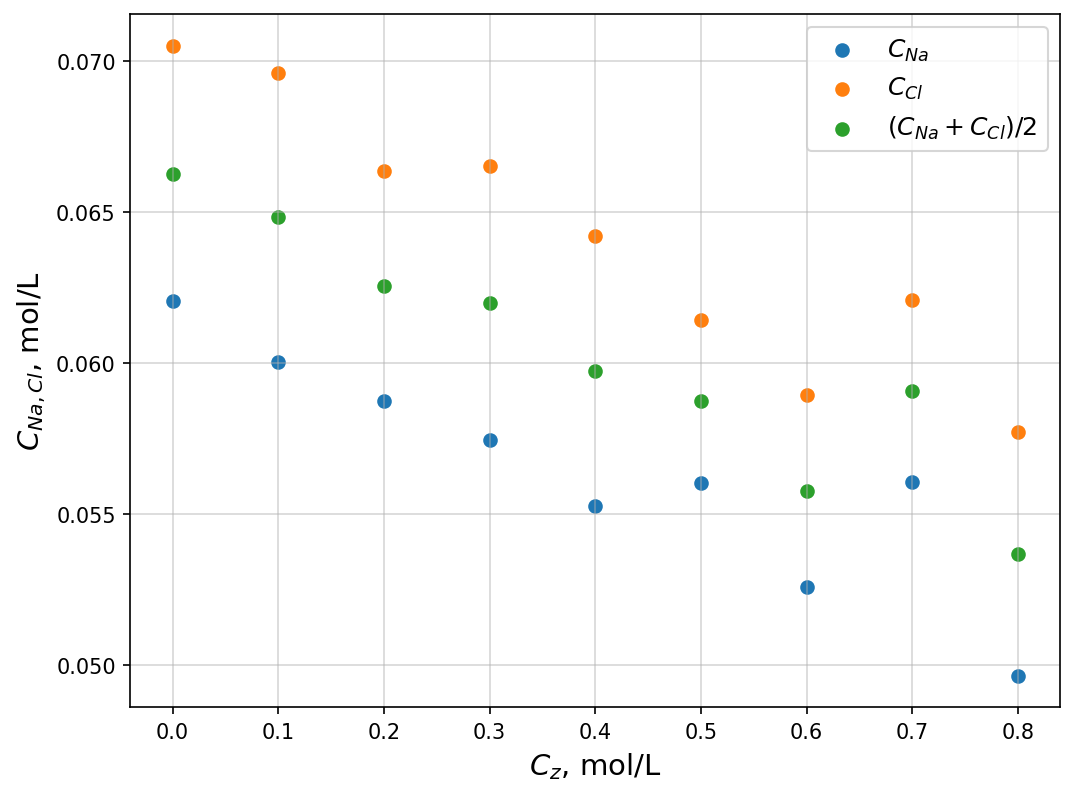

In [78]:
plt.figure(figsize=(8, 6), dpi=150)
plt.grid(alpha=0.5)

plt.scatter(C_z_list, C_Na_list, label=r'$C_{Na}$')
plt.scatter(C_z_list, C_Cl_list, label=r'$C_{Cl}$')
plt.scatter(C_z_list, (np.array(C_Na_list) + np.array(C_Cl_list)) / 2, label=r'$(C_{Na}+C_{Cl})/2$')
plt.xlabel(r'$C_z$, mol/L', fontsize=14)
plt.ylabel(r'$C_{Na, Cl}$, mol/L', fontsize=14)
plt.legend(fontsize=12)
plt.show()


In [43]:
list(data.keys())

['z_edges',
 'z_centers',
 'bin_volume',
 'frame_indices',
 'species',
 'n_bins',
 'Na_number_density',
 'Na_mean_counts',
 'Cl_number_density',
 'Cl_mean_counts',
 'total_number_density']

In [35]:
data['z_centers']

array([0.02, 0.06, 0.1 , 0.14, 0.18, 0.22, 0.26, 0.3 , 0.34, 0.38, 0.42,
       0.46, 0.5 , 0.54, 0.58, 0.62, 0.66, 0.7 , 0.74, 0.78, 0.82, 0.86,
       0.9 , 0.94, 0.98, 1.02, 1.06, 1.1 , 1.14, 1.18, 1.22, 1.26, 1.3 ,
       1.34, 1.38, 1.42, 1.46, 1.5 , 1.54, 1.58, 1.62, 1.66, 1.7 , 1.74,
       1.78, 1.82, 1.86, 1.9 , 1.94, 1.98, 2.02, 2.06, 2.1 , 2.14, 2.18,
       2.22, 2.26, 2.3 , 2.34, 2.38, 2.42, 2.46, 2.5 , 2.54, 2.58, 2.62,
       2.66, 2.7 , 2.74, 2.78, 2.82, 2.86, 2.9 , 2.94, 2.98, 3.02, 3.06,
       3.1 , 3.14, 3.18, 3.22, 3.26, 3.3 , 3.34, 3.38, 3.42, 3.46, 3.5 ,
       3.54, 3.58, 3.62, 3.66, 3.7 , 3.74, 3.78, 3.82, 3.86, 3.9 , 3.94,
       3.98])

In [88]:
path = 'results_prod/fig_6'

C_z_list = []
C_Na_list = []
C_Cl_list = []
# Define the exponential fitting function
def exp_func(x, a, b, c, d):
    return a * np.exp(b * x - c) + d

for folder in os.listdir(path):
    data_file = osp.join(path, folder, "density_profile_Na_Cl.npz")
    data = np.load(data_file)

    config_file = osp.join(path, folder, "config_backup.yaml")
    with open(config_file, "r") as f:
        config = yaml.safe_load(f)

    C_z_list.append(config['Cz'])

    # Fit the number density for Na
    z = data['z_centers']
    nd_Na = data['Na_number_density']
    mask_Na = z >= config['r_Na']
    z_Na_fit = z[mask_Na]
    nd_Na_fit = nd_Na[mask_Na]

    # Initial guess for curve_fit
    p0 = [nd_Na_fit.max(), -1.0, 0, nd_Na_fit.min()]
    popt_Na, _ = curve_fit(exp_func, z_Na_fit, nd_Na_fit, p0=p0)

    # Fit the number density for Cl
    z = data['z_centers']
    nd_Cl = data['Cl_number_density']
    mask_Cl = z <= config['H'] - config['r_Cl']
    z_Cl_fit = z[mask_Cl]
    nd_Cl_fit = nd_Cl[mask_Cl]

    # Initial guess for curve_fit
    p0 = [nd_Cl_fit.max(), 1.0, config['H'] - config['r_Cl'], nd_Cl_fit.min()]
    popt_Cl, _ = curve_fit(exp_func, z_Cl_fit, nd_Cl_fit, p0=p0)


    plt.figure(figsize=(10, 6))
    plt.grid(alpha=0.5)

    plt.plot(z, nd_Na * 1.66053907, lw=2, label="Na")
    plt.plot(z, nd_Cl * 1.66053907, lw=2, label="Cl")
    plt.plot(z_Na_fit, exp_func(z_Na_fit, *popt_Na) * 1.66053907, 'r--', lw=2, label="Na exp fit")
    plt.plot(z_Cl_fit, exp_func(z_Cl_fit, *popt_Cl) * 1.66053907, 'b--', lw=2, label="Cl exp fit")
    plt.legend(fontsize=12)
    plt.xlabel(r'$z$, nm', fontsize=14)
    plt.ylabel(r'$C_{Na, Cl}$, mol/L', fontsize=14)
    plt.title(
        f"Number density: Na, Cl\n"
        f"C: {config['C']}, Cz: {config['Cz']}, H: {config['H']}, psi: {config['psi']}, pz: {config['pz']}"
    )
    # plt.show()
    plt.savefig(osp.join(path, folder, "density_profile_Na_Cl_fit.png"), dpi=150)
    plt.close()
